# Reusable Template: Hypothesis Testing & Power Analysis Project

Copy this notebook as the starting point for a new project. It's organized as a pipeline:

1. **Config** — set your study's parameters in one place.
2. **Data loading** — plug in your real data source.
3. **Exploratory checks** — sanity checks before you trust a z-test.
4. **Test-selection helper** — a function that nudges you toward the right test.
5. **Reusable test runner functions** — one function per test family, used consistently.
6. **Power analysis functions** — planning and post-hoc power in one place.
7. **Reporting** — a consistent, four-step write-up generator.

Sections you don't need for a given project can simply be skipped — the functions are independent
of each other.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math

from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import (
    TTestPower, TTestIndPower, NormalIndPower,
    GofChisquarePower, FTestPower, FTestAnovaPower
)
from statsmodels.stats.gof import chisquare_effectsize

plt.rcParams['figure.figsize'] = (7, 4)


## 1. Config

Edit these values for your project. Keeping them in one cell makes the rest of the notebook reusable without hunting for magic numbers.

In [2]:
CONFIG = {
    "alpha": 0.05,                 # significance level (Type I error rate)
    "desired_power": 0.80,         # target power for planning sample sizes
    "confidence_level": 0.95,      # for confidence intervals (should be 1 - alpha, by convention)
    "sigma_known": False,          # set True only if the population std dev is genuinely known
    "random_seed": 42,             # for any simulation / reproducibility
}
np.random.seed(CONFIG["random_seed"])


## 2. Data loading

Replace the placeholder below with your actual data source (`pd.read_csv(...)`, a database query, an API pull, etc.). Keep raw data in `df` and derive working variables from it explicitly, so re-running this cell with new data doesn't require touching the rest of the notebook.

In [3]:
# TODO: replace with your real data source, e.g.:
# df = pd.read_csv("your_data.csv")

# Placeholder example structure -- delete once you have real data:
df = pd.DataFrame({
    "group": ["control"] * 25 + ["treatment"] * 25,
    "value": np.concatenate([
        np.random.normal(100, 15, 25),
        np.random.normal(108, 15, 25),
    ])
})
df.head()

,group,value
0,control,107.450712
1,control,97.926035
2,control,109.715328
3,control,122.845448
4,control,96.487699


## 3. Exploratory checks

Before trusting a z-test (or t-test), sanity-check the assumptions: roughly-normal shape, no extreme outliers, plausible independence, and adequate sample size (n > ~30 is the common rule of thumb for the CLT to kick in).

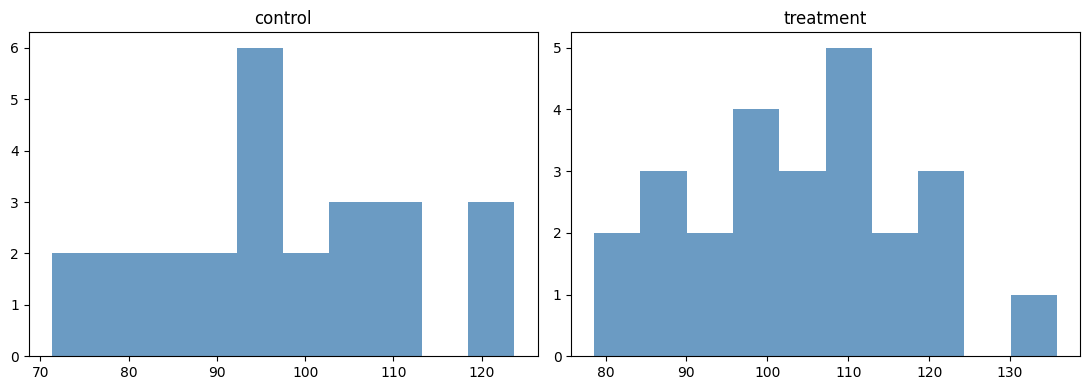

--- control ---
n = 25, mean = 97.547, std = 14.348
skewness = 0.109, kurtosis = -0.551
shapiro-wilk normality test p-value = 0.6353 (low p-value suggests non-normality)
--- treatment ---
n = 25, mean = 103.688, std = 13.885
skewness = 0.154, kurtosis = -0.347
shapiro-wilk normality test p-value = 0.9635 (low p-value suggests non-normality)


In [4]:
def explore_group(data, label=""):
    data = np.asarray(data)
    print(f"--- {label} ---")
    print(f"n = {len(data)}, mean = {data.mean():.3f}, std = {data.std(ddof=1):.3f}")
    print(f"skewness = {stats.skew(data):.3f}, kurtosis = {stats.kurtosis(data):.3f}")
    print(f"shapiro-wilk normality test p-value = {stats.shapiro(data).pvalue:.4f} "
          f"(low p-value suggests non-normality)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, sub) in zip(axes, df.groupby("group")["value"]):
    ax.hist(sub, bins=10, color="steelblue", alpha=0.8)
    ax.set_title(name)
plt.tight_layout()
plt.show()

for name, sub in df.groupby("group")["value"]:
    explore_group(sub, label=name)

## 4. Test-selection helper

A lightweight decision helper -- not a substitute for judgment, but a reminder of the branch points that matter most.

In [5]:
def suggest_test(n_groups=2, comparing="means", sigma_known=False, paired=False, n_per_group=30):
    """
    Print a suggested test family given basic study characteristics.
    This is a nudge, not an authority -- always sanity-check against your actual data.
    """
    if comparing == "means":
        if n_groups == 1:
            test = "one-sample z-test" if sigma_known else "one-sample t-test"
        elif n_groups == 2:
            if paired:
                test = "paired t-test (not covered in this bundle)"
            else:
                test = "two-sample z-test" if sigma_known else "two-sample t-test"
        else:
            test = "one-way ANOVA (F-test)"
    elif comparing == "proportions":
        test = "one-proportion z-test" if n_groups == 1 else "two-proportion z-test"
    elif comparing == "category_counts":
        test = "chi-square goodness-of-fit test"
    elif comparing == "variances":
        test = "F-test"
    else:
        test = "unrecognized comparison type -- specify one of: means, proportions, category_counts, variances"

    if comparing == "means" and n_per_group < 30 and not sigma_known:
        test += "  (WARNING: n < 30 and sigma unknown -- normality assumption is more fragile here)"

    print(f"Suggested approach: {test}")
    return test

suggest_test(n_groups=2, comparing="means", sigma_known=CONFIG["sigma_known"], n_per_group=25)

Suggested approach: two-sample t-test  (WARNING: n < 30 and sigma unknown -- normality assumption is more fragile here)


'two-sample t-test  (WARNING: n < 30 and sigma unknown -- normality assumption is more fragile here)'

## 5. Reusable test-runner functions

One function per test family. Each returns a plain dict so results are easy to log, compare across runs, or feed into a reporting step.

In [6]:
def run_one_sample_mean_test(sample, mu0, sigma=None, alternative='two-sided', alpha=None):
    """
    z-test if sigma is provided (assumed known); t-test otherwise.
    alternative: 'two-sided', 'larger', or 'smaller'
    """
    alpha = CONFIG["alpha"] if alpha is None else alpha
    sample = np.asarray(sample)
    n = len(sample)
    xbar = sample.mean()

    if sigma is not None:
        z_stat = (xbar - mu0) / (sigma / math.sqrt(n))
        if alternative == 'two-sided':
            p_value = stats.norm.sf(abs(z_stat)) * 2
        elif alternative == 'larger':
            p_value = stats.norm.sf(z_stat)
        elif alternative == 'smaller':
            p_value = stats.norm.cdf(z_stat)
        else:
            raise ValueError("alternative must be 'two-sided', 'larger', or 'smaller'")
        test_type = "one-sample z-test"
        stat = z_stat
    else:
        stat, p_value = stats.ttest_1samp(sample, popmean=mu0, alternative={
            'two-sided': 'two-sided', 'larger': 'greater', 'smaller': 'less'
        }[alternative])
        test_type = "one-sample t-test"

    return {
        "test": test_type, "n": n, "xbar": xbar, "mu0": mu0,
        "statistic": stat, "p_value": p_value, "alpha": alpha,
        "reject_h0": p_value <= alpha,
    }


def run_two_sample_mean_test(sample1, sample2, alternative='two-sided', alpha=None,
                               sigma1=None, sigma2=None):
    """
    z-test if BOTH sigma1 and sigma2 are provided (assumed known); Welch's t-test otherwise.
    """
    alpha = CONFIG["alpha"] if alpha is None else alpha
    s1, s2 = np.asarray(sample1), np.asarray(sample2)

    if sigma1 is not None and sigma2 is not None:
        stat, p_value = ztest(s1, s2, value=0, alternative=alternative)
        test_type = "two-sample z-test"
    else:
        alt_map = {'two-sided': 'two-sided', 'larger': 'greater', 'smaller': 'less'}
        stat, p_value = stats.ttest_ind(s1, s2, equal_var=False, alternative=alt_map[alternative])
        test_type = "two-sample Welch's t-test"

    return {
        "test": test_type, "n1": len(s1), "n2": len(s2),
        "xbar1": s1.mean(), "xbar2": s2.mean(),
        "statistic": stat, "p_value": p_value, "alpha": alpha,
        "reject_h0": p_value <= alpha,
    }


def run_one_proportion_test(count, nobs, p0, alternative='two-sided', alpha=None):
    alpha = CONFIG["alpha"] if alpha is None else alpha
    stat, p_value = proportions_ztest(count, nobs, p0, alternative=alternative)
    return {
        "test": "one-proportion z-test", "p_hat": count / nobs, "p0": p0, "nobs": nobs,
        "statistic": stat, "p_value": p_value, "alpha": alpha,
        "reject_h0": p_value <= alpha,
    }


def run_two_proportion_test(count1, nobs1, count2, nobs2, alternative='two-sided', alpha=None):
    alpha = CONFIG["alpha"] if alpha is None else alpha
    stat, p_value = proportions_ztest([count1, count2], [nobs1, nobs2], alternative=alternative)
    return {
        "test": "two-proportion z-test",
        "p_hat1": count1 / nobs1, "p_hat2": count2 / nobs2,
        "statistic": stat, "p_value": p_value, "alpha": alpha,
        "reject_h0": p_value <= alpha,
    }


In [7]:
# Example usage against the placeholder data loaded in Section 2
control = df.loc[df["group"] == "control", "value"]
treatment = df.loc[df["group"] == "treatment", "value"]

result = run_two_sample_mean_test(treatment, control, alternative='two-sided')
result

{'test': "two-sample Welch's t-test",
 'n1': 25,
 'n2': 25,
 'xbar1': np.float64(103.68840372218716),
 'xbar2': np.float64(97.54737912012862),
 'statistic': np.float64(1.5378448399524394),
 'p_value': np.float64(0.1306602048811365),
 'alpha': 0.05,
 'reject_h0': np.False_}

## 6. Power analysis functions

Two flavors: **planning** (given a target effect size and power, how many samples do I need?) and **post-hoc / diagnostic** (given the n I have, how much power did I actually have?). Keep both in your back pocket.

In [8]:
def cohens_d_from_samples(sample1, sample2):
    s1, s2 = np.asarray(sample1), np.asarray(sample2)
    n1, n2 = len(s1), len(s2)
    pooled_sd = math.sqrt(((n1-1)*s1.std(ddof=1)**2 + (n2-1)*s2.std(ddof=1)**2) / (n1+n2-2))
    return abs(s1.mean() - s2.mean()) / pooled_sd


def plan_sample_size_two_means(effect_size, power=None, alpha=None, ratio=1.0):
    power = CONFIG["desired_power"] if power is None else power
    alpha = CONFIG["alpha"] if alpha is None else alpha
    engine = NormalIndPower() if CONFIG["sigma_known"] else TTestIndPower()
    n = engine.solve_power(effect_size=effect_size, power=power, ratio=ratio, alpha=alpha)
    return math.ceil(n)


def achieved_power_two_means(effect_size, n1, ratio=1.0, alpha=None):
    alpha = CONFIG["alpha"] if alpha is None else alpha
    engine = NormalIndPower() if CONFIG["sigma_known"] else TTestIndPower()
    return engine.solve_power(effect_size=effect_size, nobs1=n1, ratio=ratio, alpha=alpha)


def plan_sample_size_two_proportions(p1, p2, power=None, alpha=None, ratio=1.0):
    power = CONFIG["desired_power"] if power is None else power
    alpha = CONFIG["alpha"] if alpha is None else alpha
    effect = proportion_effectsize(p1, p2)
    n = NormalIndPower().solve_power(effect_size=effect, power=power, ratio=ratio, alpha=alpha)
    return math.ceil(n), effect


def power_curve_two_means(effect_size, n_range, ratio=1.0, alpha=None, ax=None):
    alpha = CONFIG["alpha"] if alpha is None else alpha
    engine = NormalIndPower() if CONFIG["sigma_known"] else TTestIndPower()
    powers = [engine.solve_power(effect_size=effect_size, nobs1=n, ratio=ratio, alpha=alpha)
              for n in n_range]
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(n_range, powers, marker='o')
    ax.axhline(CONFIG["desired_power"], color='red', linestyle='--',
               label=f'Target power = {CONFIG["desired_power"]}')
    ax.set_xlabel('Sample size per group')
    ax.set_ylabel('Power')
    ax.legend()
    return powers


Observed Cohen's d: 0.435
Sample size needed per group for target power: 84
Achieved power with current n: 0.326


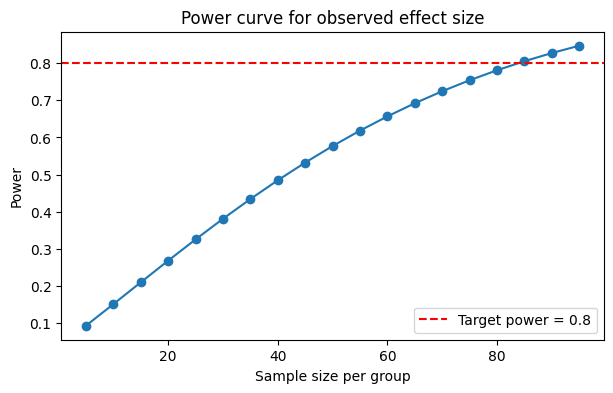

In [9]:
# Example usage
d = cohens_d_from_samples(treatment, control)
print("Observed Cohen's d:", round(d, 3))
print("Sample size needed per group for target power:", plan_sample_size_two_means(d))
print("Achieved power with current n:", round(achieved_power_two_means(d, n1=len(treatment)), 3))

power_curve_two_means(d, np.arange(5, 100, 5))
plt.title("Power curve for observed effect size")
plt.show()

## 7. Reporting

A consistent write-up generator following the four hypothesis-test steps: state the hypotheses, report the statistic/decision, give an effect size and interval where relevant, and state the scope of inference.

In [10]:
def report(result, effect_size=None, ci=None, scope_of_inference_note=""):
    """
    Print a standardized report from a result dict produced by one of the run_* functions above.
    """
    print("=" * 60)
    print(f"TEST: {result['test']}")
    print(f"Statistic = {result['statistic']:.4f} | p-value = {result['p_value']:.6f} "
          f"| alpha = {result['alpha']}")
    decision = "REJECT H0" if result["reject_h0"] else "FAIL TO REJECT H0"
    print(f"Decision: {decision}")
    if effect_size is not None:
        print(f"Effect size: {effect_size:.3f}")
    if ci is not None:
        print(f"Confidence interval: ({ci[0]:.4f}, {ci[1]:.4f})")
    if scope_of_inference_note:
        print(f"Scope of inference: {scope_of_inference_note}")
    print("=" * 60)


# Example usage tying everything together
result = run_two_sample_mean_test(treatment, control, alternative='two-sided')
d = cohens_d_from_samples(treatment, control)
report(
    result,
    effect_size=d,
    scope_of_inference_note="Applies only to the population and time window this sample was drawn from."
)

TEST: two-sample Welch's t-test
Statistic = 1.5378 | p-value = 0.130660 | alpha = 0.05
Decision: FAIL TO REJECT H0
Effect size: 0.435
Scope of inference: Applies only to the population and time window this sample was drawn from.


## Notes for adapting this template

- Swap the placeholder data in Section 2 for your real source, and update `CONFIG["sigma_known"]`
  honestly — default to `False` unless you have a genuine, independent reason to know σ.
- If your data is proportions/counts, use the proportion or chi-square functions instead of the
  mean functions; the reporting function works with any result dict that has the same keys.
- If your data fails the normality checks in Section 3, either switch to a non-parametric test
  (not included in this bundle) or use a Monte Carlo power analysis (see
  `01_extended_lab.ipynb`, Part G) instead of the closed-form power functions in Section 6.
- Keep `CONFIG` as the single source of truth for alpha/power/confidence — changing it there
  propagates through every function that reads from it.
